# Trajectory classification — Long-GEC-MLP (full latent, no FDR)

**Task: trajectory classification.** Visits are flattened into a single
fixed-width feature vector (**all** GAAE latent dims × MAX_VISITS + Δt + mask)
and passed to an MLP. No temporal ordering is preserved — this is a
*static* whole-trajectory classifier, NOT early detection.

This is the **no-FDR-compression** counterpart of
`LONGITUDINAL_GEC_FDR_DELCODE.ipynb`: instead of selecting the top-K
Fisher-discriminant latent dims, every latent dimension is fed to the MLP.
Use the two side by side to measure how much the FDR bottleneck contributes
to generalisation.


In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint/threshold prompts, JSON-config loading).
EXPERIMENT_ID = None
MODE = None
MODEL = None
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None        # required when THRESHOLD_MODE is fixed
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to outputs/<experiment-id>/ when run standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict; overrides on-disk JSON when set
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name


In [2]:
# Parameters
EXPERIMENT_ID = "gec-trajectory-whole-brain"
MODE = "longitudinal"
MODEL = "GEC"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = "notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth"
THRESHOLD_MODE = "best-f1"
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/gec-trajectory-whole-brain"
RESOLVED_CONFIG = {"epochs": 80, "lr": 0.001, "batch_size": 32, "grad_clip": 1.0, "early_stopping_patience": 20, "use_scheduler": True, "seed": 42, "wandb_project": "ad-early-detection", "wandb_enabled": True, "threshold_mode": "youden", "fixed_threshold": 0.5, "lr_factor": 0.5, "lr_patience": 5, "lr_min": 1e-06, "max_visits": None, "mlp_hidden_layers": [256, 128, 64], "mlp_dropout": 0.4, "use_time_delta": True, "append_visit_mask": True, "learning_rate": 0.001, "n_folds": 5, "adjacency_k": 8, "file_variant": "z_transformed"}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gec-trajectory-whole-brain/runs/orange-harbor-5-2e7594f8d-2026-06-20_19-32-56"
RUN_NAME = "orange-harbor-5-2e7594f8d-2026-06-20_19-32-56"


# Longitudinal GEC-MLP (full latent) — Whole-Brain FC Baseline

**Architecture**: Frozen GAAE encoder → **all** latent dimensions per visit → flattened longitudinal vector + time deltas → MLP classifier.

This is the **longitudinal baseline** for comparison against the GELSTM:
instead of processing visits sequentially (LSTM), the MLP receives all visits at once as a fixed-size padded vector `[z_1, z_2, …, z_Nmax, Δt_1, …, Δt_Nmax, mask]`.

**Key design decisions**:
- No FDR dimension selection — the full GAAE latent space is used per visit (the FDR-compressed variant lives in `LONGITUDINAL_GEC_FDR_DELCODE.ipynb`)
- Variable-length sequences are handled by zero-padding to `MAX_VISITS` and appending a binary visit-presence mask
- Features are still standardised per fold with a `StandardScaler` (fit on train only)

In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# v2 reproducibility seeding — must run before datasets, samplers, or models.
from CLASSIFIER.common.seeding import (
    set_seed, make_rng, make_torch_generator, seed_worker,
)
SEED = 42
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)


In [5]:
import json, os, copy, warnings, glob as _glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report
)
from torch_geometric.utils import unbatch
from torch_geometric.loader import DataLoader as PyGLoader
from model.GAAE.models   import GraphAttentionAutoencoderConditioned
from model.GAAE.dataset  import GraphDatasetInMemoryFiltered
from model.GAAE.utils    import knn_binary_adjacency_matrix_no_diag
from model.GELSTM.dataset import LongitudinalSubjectDataset
from common.provenance import (
    region_from_data_root, make_run_dir, snapshot_source,
    save_full_checkpoint, write_run_summary, patch_run_summary,
    capture_env, capture_git_provenance,
)
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## Configuration

In [7]:
import sys
if '/mnt/e/fyassine/ad-early-detection' not in sys.path:
    sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection')
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────
WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts.csv')
SPLITS_DIR   = str(splits_dir('downstream'))
TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')

# Brain region / atlas parsed from the DATA directory name. Surfaced in the run
# name and stored in the run config so the input data is visible at a glance.
DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION    = DATA_INFO['region']
print(f"Input data: region={DATA_INFO['region']}  atlas={DATA_INFO['atlas']}  ({DATA_INFO['dataset_dir']})")

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gaae_whole_brain'),
]
OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_longitudinal_gec_mlp_full')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── GAAE encoder config (must match checkpoint) ──────────────────────────
CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'

# ── This notebook's training hyper-params (loaded from configs/, inline fallback) ─
# No `top_k`: this notebook uses the full GAAE latent space (set after the GAAE
# config is loaded, so TOP_K == GAAE_LATENT).
TRAIN_CONFIG_PATH = model_root / 'configs' / 'long_gec_mlp_full_delcode.json'
_train_defaults = {
    'max_visits': None, 'mlp_hidden_layers': [256, 128, 64],
    'mlp_dropout': 0.4, 'use_time_delta': True, 'append_visit_mask': True,
    'learning_rate': 1e-3, 'epochs': 80, 'early_stopping_patience': 20,
    'batch_size': 32, 'grad_clip': 1.0, 'n_folds': 5,
    'adjacency_k': 8, 'file_variant': 'z_transformed',
}
if TRAIN_CONFIG_PATH.exists():
    with open(TRAIN_CONFIG_PATH) as _f:
        TRAIN_CONFIG = json.load(_f)
    print(f'Loaded training config from {TRAIN_CONFIG_PATH}')
else:
    TRAIN_CONFIG = _train_defaults
    print(f'Training config not found at {TRAIN_CONFIG_PATH} — using inline defaults.')

# Runner override: merge injected RESOLVED_CONFIG (YAML hyperparams) over JSON config.
if RESOLVED_CONFIG:
    TRAIN_CONFIG = {**TRAIN_CONFIG, **RESOLVED_CONFIG}
    print('Applied RESOLVED_CONFIG overrides from runner.')

# TOP_K is set in the GAAE-config cell to the full latent dim (no FDR selection).
MAX_VISITS              = TRAIN_CONFIG['max_visits']   # None → auto-detect after dataset discovery
MLP_HIDDEN_LAYERS       = TRAIN_CONFIG['mlp_hidden_layers']
MLP_DROPOUT             = TRAIN_CONFIG['mlp_dropout']
USE_TIME_DELTA          = TRAIN_CONFIG['use_time_delta']
APPEND_VISIT_MASK       = TRAIN_CONFIG['append_visit_mask']
LEARNING_RATE           = TRAIN_CONFIG['learning_rate']
EPOCHS                  = TRAIN_CONFIG['epochs']
EARLY_STOPPING_PATIENCE = TRAIN_CONFIG['early_stopping_patience']
BATCH_SIZE              = TRAIN_CONFIG['batch_size']
GRAD_CLIP               = TRAIN_CONFIG['grad_clip']
N_FOLDS                 = TRAIN_CONFIG['n_folds']
ADJ_K                   = TRAIN_CONFIG['adjacency_k']
FILE_VARIANT            = TRAIN_CONFIG['file_variant']

print('Config set.')

Input data: region=wholebrain  atlas=sch200  (__fc_wholebrain_sch200_flat__)
Loaded training config from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/configs/long_gec_mlp_full_delcode.json
Applied RESOLVED_CONFIG overrides from runner.
Config set.


In [8]:
# v2 split-hygiene audit — hard-fails if any subject crosses splits.
import sys
from pathlib import Path
_REPO_ROOT = Path('/mnt/e/fyassine/ad-early-detection')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
_V2_ROOT = _REPO_ROOT / 'CLASSIFIER'
if str(_V2_ROOT) not in sys.path:
    sys.path.insert(0, str(_V2_ROOT))
from common.sanity import run_full_audit
from DATA.src.splitting.load_splits import split_csv_paths
_ = run_full_audit(split_csv_paths('downstream'))


[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Select GAAE Checkpoint

In [9]:
checkpoint_candidates = sorted(
    [(run_dir.name, str(run_dir / f'model_{run_dir.name}.pth'), str(run_dir))
     for ckpt_dir in CHECKPOINT_SEARCH_DIRS
     for base_path in [Path(ckpt_dir)] if base_path.is_dir()
     for run_dir in sorted(base_path.iterdir()) if run_dir.is_dir()
     if (run_dir / f'model_{run_dir.name}.pth').exists()],
    key=lambda x: x[0],
)
if not checkpoint_candidates:
    raise FileNotFoundError('No GAAE checkpoints found in CHECKPOINT_SEARCH_DIRS.')
print('Available GAAE checkpoints:')
for i, (name, _, _) in enumerate(checkpoint_candidates): print(f'  {i}: {name}')
if GAAE_CHECKPOINT_PATH is not None:
    _t = str(Path(GAAE_CHECKPOINT_PATH).resolve())
    _m = [c for c in checkpoint_candidates if str(Path(c[1]).resolve()) == _t]
    if not _m:
        raise FileNotFoundError(f'GAAE_CHECKPOINT_PATH={GAAE_CHECKPOINT_PATH!r} not among '
                                f'candidates: {[c[1] for c in checkpoint_candidates]}')
    GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = _m[0]
elif RUN_DIR is not None:
    raise ValueError(
        "GAAE_CHECKPOINT_PATH is required under the experiment runner. "
        "Set 'checkpoint_path:' on this entry in experiments.yaml."
    )
else:
    selected_idx = int(input('Select checkpoint index: '))
    GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = checkpoint_candidates[selected_idx]
print(f'Selected: {GAAE_RUN_NAME}')


Available GAAE checkpoints:
  0: ethereal-planet-16_2026-06-10_12-31-05
Selected: ethereal-planet-16_2026-06-10_12-31-05


## Load GAAE Config

In [10]:
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f: hp = json.load(f)
    print('Config:', hp)
else:
    hp = dict(latent_dim=64, hidden_dim=128, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
    print('Using defaults.')

IN_FEATURES   = 200
GAAE_HIDDEN   = hp.get('hidden_dim', 128)
GAAE_LATENT   = hp.get('latent_dim', 64)
GAAE_HEADS    = hp.get('num_heads', 2)
GAAE_COND_DIM = hp.get('cond_dim', 2)
GAAE_DROPOUT  = hp.get('dropout', 0.3)
ADJ_K         = hp.get('adjacency_k', ADJ_K)
FILE_VARIANT  = hp.get('file_variant', FILE_VARIANT)

# No FDR selection: use every latent dimension.
TOP_K = GAAE_LATENT
print(f'GAAE hidden dim: {GAAE_HIDDEN}  latent dim: {GAAE_LATENT}  →  using all {TOP_K} latent dims (no FDR)')


Config: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001, 'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25, 'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'}
GAAE hidden dim: 128  latent dim: 64  →  using all 64 latent dims (no FDR)


## Load Splits & GAAE Encoder (full latent — no FDR)

No Fisher-discriminant dimension selection here: every GAAE latent dimension
is used per visit (`DIM_FILTER = all dims`). The FDR-compressed counterpart
lives in `LONGITUDINAL_GEC_FDR_DELCODE.ipynb`.

In [11]:
# Load split CSVs. CV pool = train+val (test held out).
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
mci_pool   = cv_pool_df.copy()
test_mci   = test_df.copy()

print('CV pool:', mci_pool['diagnosis'].value_counts().to_dict())
print('Test:   ', test_mci['diagnosis'].value_counts().to_dict())


CV pool: {'mci': 79, 'converter': 54}
Test:    {'mci': 20, 'converter': 14}


In [12]:
# Load the frozen GAAE encoder (used to embed each visit graph).
gaae_enc = GraphAttentionAutoencoderConditioned(
    in_features=IN_FEATURES, hidden_dim=GAAE_HIDDEN,
    out_features=GAAE_LATENT, cond_dim=GAAE_COND_DIM,
    num_heads=GAAE_HEADS, dropout=GAAE_DROPOUT,
).to(device)
ckpt_obj = torch.load(GAAE_CKPT_PATH, map_location=device, weights_only=False)
gaae_enc.load_state_dict(ckpt_obj if isinstance(ckpt_obj, dict) else ckpt_obj.state_dict())
gaae_enc.eval()
for p in gaae_enc.parameters(): p.requires_grad_(False)
print('GAAE encoder loaded and frozen.')


GAAE encoder loaded and frozen.


In [13]:
# No FDR selection — use every latent dimension. DIM_FILTER is the identity
# selection so the downstream encode/records code is shared with the FDR variant.
DIM_FILTER = np.arange(GAAE_LATENT)
print(f'Using all {len(DIM_FILTER)} latent dims (no FDR compression).')


Using all 64 latent dims (no FDR compression).


## Build Longitudinal Flat-Vector Dataset

For each subject, collect all scans in visit order:
1. Encode each scan through the frozen GAAE → `z_t[DIM_FILTER] ∈ R^TOP_K`
2. Compute inter-visit time deltas `Δt_t` (normalised)
3. Pad to `MAX_VISITS`: `[z_1, …, z_N, 0, …, 0]` + `[mask_1, …, mask_N, 0, …, 0]`
4. Final per-subject feature vector: `TOP_K × MAX_VISITS + MAX_VISITS (Δt) + MAX_VISITS (mask)`

In [14]:
def encode_graph_to_z(data):
    """Encode a PyG Data graph to a per-graph embedding using the frozen GAAE."""
    x  = data.x.to(device)
    ei = data.edge_index.to(device)
    ea = data.edge_attr.to(device) if data.edge_attr is not None else None
    z_nodes = gaae_enc.encode(x, ei, ea)       # (N_nodes, GAAE_LATENT)
    z_graph = z_nodes.mean(0).cpu().numpy()    # (GAAE_LATENT,)
    return z_graph[DIM_FILTER]                 # (TOP_K,)


def build_longitudinal_dataset(subject_dataset: LongitudinalSubjectDataset):
    """
    Returns (X, y, groups) where:
      X      : (N_subjects, feature_dim)  padded flat longitudinal vector
      y      : (N_subjects,)              labels {0,1}
      groups : list of subject IDs for StratifiedGroupKFold
    """
    records = []
    gaae_enc.eval()
    with torch.no_grad():
        for i in range(len(subject_dataset)):
            item = subject_dataset[i]
            graphs = item['graphs']     # list of PyG Data, chronological order
            deltas = item['delta_t']    # list of normalised Δt values
            label  = item['label']      # 0=MCI, 1=converter
            pid    = item['subject_id']
            T      = len(graphs)
            zs  = [encode_graph_to_z(g) for g in graphs]  # list of (TOP_K,)
            dts = list(deltas)
            records.append({'pid': pid, 'label': label, 'T': T, 'zs': zs, 'dts': dts})
    return records


def records_to_arrays(records, max_visits, n_visits=None):
    """Convert records to padded numpy arrays.

    n_visits: if set, truncate each record to its first `n_visits` visits
    (capped at max_visits) before padding — used for early-detection
    ("first-N-visits") evaluation. Default (None) uses each record's full
    visit history, capped at max_visits.
    """
    n    = len(records)
    k    = TOP_K
    X_z  = np.zeros((n, max_visits * k),   dtype=np.float32)  # latent features
    X_dt = np.zeros((n, max_visits),        dtype=np.float32)  # time deltas
    X_m  = np.zeros((n, max_visits),        dtype=np.float32)  # visit mask
    y    = np.zeros(n,                      dtype=np.float32)
    groups = []

    cap = max_visits if n_visits is None else min(n_visits, max_visits)
    for i, rec in enumerate(records):
        T = min(rec['T'], cap)
        for t in range(T):
            X_z[i, t*k:(t+1)*k] = rec['zs'][t]
            X_dt[i, t]          = rec['dts'][t]
            X_m[i, t]           = 1.0
        y[i] = float(rec['label'])
        groups.append(rec['pid'])

    parts = [X_z]
    if USE_TIME_DELTA:    parts.append(X_dt)
    if APPEND_VISIT_MASK: parts.append(X_m)
    X = np.concatenate(parts, axis=1)
    return X.astype(np.float32), y.astype(np.float32), groups


In [15]:
# Build longitudinal datasets
cv_long_ds = LongitudinalSubjectDataset(
    WB_DATA_ROOT, mci_pool, COHORTS_CSV, adjacency_k=ADJ_K, file_variant=FILE_VARIANT
)
te_long_ds = LongitudinalSubjectDataset(
    WB_DATA_ROOT, test_mci, COHORTS_CSV, adjacency_k=ADJ_K, file_variant=FILE_VARIANT
)
print(f'CV subjects: {len(cv_long_ds)}  Test subjects: {len(te_long_ds)}')

# Auto-detect MAX_VISITS from CV pool
print('Discovering visit counts...')
visit_counts = [len(cv_long_ds[i]['graphs']) for i in range(len(cv_long_ds))]
if MAX_VISITS is None:
    MAX_VISITS = int(max(visit_counts))
print(f'MAX_VISITS = {MAX_VISITS}  (distribution: {pd.Series(visit_counts).value_counts().sort_index().to_dict()})')

# Encode all subjects into longitudinal flat vectors
print('Encoding CV pool...')
cv_records = build_longitudinal_dataset(cv_long_ds)
X_cv, y_cv, groups_cv = records_to_arrays(cv_records, MAX_VISITS)

print('Encoding test set...')
te_records = build_longitudinal_dataset(te_long_ds)
X_te, y_te, groups_te = records_to_arrays(te_records, MAX_VISITS)

feat_dim = X_cv.shape[1]
print(f'CV array: {X_cv.shape}  Test array: {X_te.shape}')
print(f'Feature dim breakdown: {TOP_K}×{MAX_VISITS}={TOP_K*MAX_VISITS} (z) + '
      f'{MAX_VISITS} (Δt) + {MAX_VISITS} (mask) = {feat_dim}')


LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=3.0
LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9
CV subjects: 133  Test subjects: 34
Discovering visit counts...


MAX_VISITS = 6  (distribution: {1: 26, 2: 36, 3: 21, 4: 19, 5: 18, 6: 13})
Encoding CV pool...


Encoding test set...


CV array: (133, 396)  Test array: (34, 396)
Feature dim breakdown: 64×6=384 (z) + 6 (Δt) + 6 (mask) = 396


## MLP Model Architecture

Input: `TOP_K × MAX_VISITS + MAX_VISITS (Δt) + MAX_VISITS (mask)` flat vector

The MLP sees the entire visit history simultaneously — no temporal order is assumed. This is the key difference vs. the LSTM, which processes visits sequentially and is sensitive to temporal ordering. The MLP comparison tells us whether temporal ordering/recurrence actually helps beyond having all the data in one vector.

In [16]:
class LongitudinalMLP(nn.Module):
    """
    MLP classifier for longitudinal data.
    Input: padded flat vector [z_1,...,z_Nmax, Δt_1,..., Δt_Nmax, mask_1,...,mask_Nmax]
    """
    def __init__(self, input_dim: int, hidden_layers: list[int], dropout: float = 0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, input_dim) → (B,) logits."""
        return self.net(x).squeeze(-1)


def build_mlp():
    m = LongitudinalMLP(
        input_dim=feat_dim,
        hidden_layers=MLP_HIDDEN_LAYERS,
        dropout=MLP_DROPOUT,
    ).to(device)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'LongitudinalMLP: input={feat_dim}  params={n_params:,}')
    return m

_ = build_mlp()


LongitudinalMLP: input=396  params=143,745


## 5-Fold Stratified Subject-Level Cross-Validation

In [17]:
# Standardise features on train split only (fit per fold)
cv_results = {'fold':[],'val_auc':[],'val_sensitivity':[],'val_specificity':[],'val_f1':[],'best_threshold':[]}
cv_histories = {'train_loss':[],'val_loss':[]}
oof_probs, oof_tgts, oof_sids = [], [], []

best_val_auc, best_fold, best_model_state = 0.0, -1, None
best_threshold_overall = 0.5

from common import tracking
_wb_exp = {'id': EXPERIMENT_ID or 'gec-trajectory', 'mode': MODE or 'longitudinal', 'model': MODEL or 'GEC', 'dataset': DATASET or REGION, 'seed': SEED, 'wandb': WANDB_ENABLED}
wandb_run = tracking.init_run(_wb_exp, {**(RESOLVED_CONFIG or {}), 'REGION': REGION})

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS)

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X_cv, y_cv, groups=groups_cv)):
    print(f'\n{"="*55}')
    print(f'Fold {fold+1}/{N_FOLDS}  train={len(tr_idx)}  val={len(va_idx)}')

    X_tr_raw, y_tr = X_cv[tr_idx], y_cv[tr_idx]
    X_va_raw, y_va = X_cv[va_idx], y_cv[va_idx]

    # Standardise on train fold only
    scaler = StandardScaler().fit(X_tr_raw)
    X_tr   = torch.tensor(scaler.transform(X_tr_raw), dtype=torch.float32)
    X_va   = torch.tensor(scaler.transform(X_va_raw), dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.float32)

    # Class-weighted loss
    n_pos = int(y_tr.sum()); n_neg = len(y_tr) - n_pos
    pos_w = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    model = build_mlp()
    opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=7)

    tr_ds = torch.utils.data.TensorDataset(X_tr, y_tr_t)
    tr_dl = torch.utils.data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_fold_auc, no_improve = 0.0, 0
    best_fold_state = None
    fold_tr_losses, fold_va_aucs = [], []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            opt.zero_grad(); loss.backward()
            if GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            total_loss += loss.item()
        tr_loss = total_loss / max(len(tr_dl), 1)

        model.eval()
        with torch.no_grad():
            logits_va = model(X_va.to(device))
            probs_va  = torch.sigmoid(logits_va).cpu().numpy()
        va_auc = roc_auc_score(y_va, probs_va) if len(np.unique(y_va)) > 1 else 0.0
        sched.step(va_auc)
        tracking.log_metrics(wandb_run, {'fold': fold+1, 'epoch': epoch+1, 'train_loss': tr_loss, 'val_auc': va_auc})

        fold_tr_losses.append(tr_loss)
        fold_va_aucs.append(va_auc)

        if (epoch + 1) % 10 == 0:
            print(f'  Ep {epoch+1:3d}/{EPOCHS}  loss={tr_loss:.4f}  val_auc={va_auc:.4f}')

        if va_auc > best_fold_auc:
            best_fold_auc = va_auc
            best_fold_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= EARLY_STOPPING_PATIENCE:
                print(f'  Early stop at epoch {epoch+1}')
                break

    # Reload best and evaluate
    model.load_state_dict(best_fold_state)
    model.eval()
    with torch.no_grad():
        probs_va2 = torch.sigmoid(model(X_va.to(device))).cpu().numpy()
    auc_fold = roc_auc_score(y_va, probs_va2) if len(np.unique(y_va)) > 1 else 0.0
    fpr_,tpr_,thr_ = roc_curve(y_va, probs_va2) if len(np.unique(y_va)) > 1 else ([0],[1],[0.5])
    best_thr = float(thr_[np.argmax(np.array(tpr_)-np.array(fpr_))])
    pred_va  = (probs_va2 >= best_thr).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_va.astype(int), pred_va).ravel() if len(np.unique(y_va)) > 1 else (0,0,0,0)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    f1   = f1_score(y_va.astype(int), pred_va, zero_division=0)

    oof_probs.extend(probs_va2.tolist())
    oof_tgts.extend(y_va.astype(int).tolist())
    oof_sids.extend([groups_cv[i] for i in va_idx])

    cv_results['fold'].append(fold+1)
    cv_results['val_auc'].append(auc_fold)
    cv_results['val_sensitivity'].append(sens)
    cv_results['val_specificity'].append(spec)
    cv_results['val_f1'].append(f1)
    cv_results['best_threshold'].append(best_thr)
    cv_histories['train_loss'].append(fold_tr_losses)
    cv_histories['val_loss'].append(fold_va_aucs)

    print(f'  Best AUC={auc_fold:.4f}  sens={sens:.3f}  spec={spec:.3f}  F1={f1:.3f}')
    if auc_fold > best_val_auc:
        best_val_auc, best_fold = auc_fold, fold+1
        best_model_state = best_fold_state
        best_threshold_overall = best_thr
        best_scaler = scaler

oof_arr = np.array(oof_probs); oof_tgt = np.array(oof_tgts)
_, _, thrs = roc_curve(oof_tgt, oof_arr)
best_f1_thr = float(thrs[np.argmax([f1_score(oof_tgt,(oof_arr>=t).astype(int),zero_division=0) for t in thrs])])
print(f'\nBest fold: {best_fold}  CV AUC={best_val_auc:.4f}')
print(f'Youden thr={best_threshold_overall:.4f}  OOF-F1 thr={best_f1_thr:.4f}')



Fold 1/5  train=106  val=27
LongitudinalMLP: input=396  params=143,745


  Ep  10/80  loss=0.3902  val_auc=0.9716
  Ep  20/80  loss=0.2171  val_auc=0.9602


  Ep  30/80  loss=0.1259  val_auc=0.9261
  Early stop at epoch 30
  Best AUC=0.9716  sens=0.909  spec=1.000  F1=0.952

Fold 2/5  train=106  val=27
LongitudinalMLP: input=396  params=143,745
  Ep  10/80  loss=0.4576  val_auc=0.8636


  Ep  20/80  loss=0.1564  val_auc=0.8750
  Ep  30/80  loss=0.1056  val_auc=0.8580


  Ep  40/80  loss=0.1075  val_auc=0.8636
  Early stop at epoch 42
  Best AUC=0.8807  sens=0.818  spec=0.938  F1=0.857

Fold 3/5  train=106  val=27
LongitudinalMLP: input=396  params=143,745


...

  Ep  10/80  loss=0.4031  val_auc=0.9563
  Ep  20/80  loss=0.2156  val_auc=0.9625


  Ep  30/80  loss=0.1323  val_auc=0.9750
  Early stop at epoch 36
  Best AUC=0.9875  sens=0.900  spec=1.000  F1=0.947

Fold 5/5  train=107  val=26
LongitudinalMLP: input=396  params=143,745


  Ep  10/80  loss=0.4061  val_auc=0.8424
  Ep  20/80  loss=0.1860  val_auc=0.8970


  Ep  30/80  loss=0.1823  val_auc=0.9273
  Ep  40/80  loss=0.1114  val_auc=0.9030


  Ep  50/80  loss=0.0975  val_auc=0.9030
  Early stop at epoch 50
  Best AUC=0.9273  sens=1.000  spec=0.733  F1=0.846

Best fold: 4  CV AUC=0.9875
Youden thr=0.9027  OOF-F1 thr=0.6536


## Cross-Validation Summary

In [18]:
print('Cross-Validation Summary (Longitudinal GEC-MLP):')
print('=' * 60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 60)
for m in ['val_auc','val_sensitivity','val_specificity','val_f1']:
    v = cv_results[m]
    print(f'{m:<20} {np.mean(v):>10.4f} {np.std(v):>10.4f} {np.min(v):>10.4f} {np.max(v):>10.4f}')


Cross-Validation Summary (Longitudinal GEC-MLP):
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.9466     0.0384     0.8807     0.9875
val_sensitivity          0.9255     0.0686     0.8182     1.0000
val_specificity          0.9092     0.0994     0.7333     1.0000
val_f1                   0.9039     0.0446     0.8462     0.9524


In [19]:
def _oof_m(thr):
    p = (oof_arr >= thr).astype(int)
    if len(np.unique(oof_tgt)) > 1:
        tn,fp,fn,tp = confusion_matrix(oof_tgt,p).ravel()
    else: tn=fp=fn=tp=0
    return tp/(tp+fn+1e-9), tn/(tn+fp+1e-9), f1_score(oof_tgt,p,zero_division=0)
y_s,y_sp,y_f1 = _oof_m(best_threshold_overall)
f_s,f_sp,f_f1 = _oof_m(best_f1_thr)
print(f'[1] Youden  thr={best_threshold_overall:.4f}  sens={y_s:.3f}  spec={y_sp:.3f}  F1={y_f1:.3f}')
print(f'[2] Best-F1 thr={best_f1_thr:.4f}  sens={f_s:.3f}  spec={f_sp:.3f}  F1={f_f1:.3f}')
if THRESHOLD_MODE == 'best-f1':
    ACTIVE_THRESHOLD = best_f1_thr; THRESHOLD_METHOD = 'oof_f1'
elif THRESHOLD_MODE == 'youden':
    ACTIVE_THRESHOLD = best_threshold_overall; THRESHOLD_METHOD = 'oof_youden'
elif THRESHOLD_MODE == 'fixed':
    if FIXED_THRESHOLD is None:
        raise ValueError("THRESHOLD_MODE='fixed' requires FIXED_THRESHOLD")
    ACTIVE_THRESHOLD = float(FIXED_THRESHOLD); THRESHOLD_METHOD = 'fixed'
elif RUN_DIR is not None:
    raise ValueError(
        "THRESHOLD_MODE is required under the experiment runner "
        "(youden | best-f1 | fixed). Set 'threshold_mode:' in experiments.yaml."
    )
else:
    choice = input('Select [1=Youden, 2=Best-F1]: ').strip()
    ACTIVE_THRESHOLD = best_f1_thr if choice == '2' else best_threshold_overall
    THRESHOLD_METHOD = 'oof_f1' if choice == '2' else 'oof_youden'
print(f'Using {THRESHOLD_METHOD}: {ACTIVE_THRESHOLD:.4f}')


[1] Youden  thr=0.9027  sens=0.519  spec=1.000  F1=0.683
[2] Best-F1 thr=0.6536  sens=0.815  spec=0.873  F1=0.815
Using oof_f1: 0.6536


## Save Best Model

In [20]:
import pickle

# Create the run directory (region embedded in the run name) and save artifacts.
if RUN_DIR:
    run_dir = Path(RUN_DIR); run_dir.mkdir(parents=True, exist_ok=True)
    run_name = RUN_NAME or run_dir.name
else:
    run_name, run_dir = make_run_dir(OUTPUT_DIR, f'long_gec_mlp_{TOP_K}dims', DATA_INFO)

# Back-compat artifacts (read by comparison notebooks): state_dict, dim filter, scaler.
torch.save(best_model_state, run_dir / f'model_{run_name}.pth')
np.save(run_dir / 'dim_filter.npy', DIM_FILTER)
with open(run_dir / 'scaler.pkl', 'wb') as _f:
    pickle.dump(best_scaler, _f)

# Record the auto-detected MAX_VISITS back into the config snapshot.
TRAIN_CONFIG = {**TRAIN_CONFIG, 'max_visits': int(MAX_VISITS)}

model_config = {
    'model_type':        'LongitudinalMLP',
    'input_dim':         int(feat_dim),
    'mlp_hidden_layers': MLP_HIDDEN_LAYERS,
    'mlp_dropout':       MLP_DROPOUT,
    'top_k':             TOP_K,
    'max_visits':        int(MAX_VISITS),
    'use_time_delta':    USE_TIME_DELTA,
    'append_visit_mask': APPEND_VISIT_MASK,
    'gaae_latent':       GAAE_LATENT,
    'gaae_heads':        GAAE_HEADS,
    'gaae_cond_dim':     GAAE_COND_DIM,
    'gaae_dropout':      GAAE_DROPOUT,
}
dataset_info = {
    **DATA_INFO,
    'train_csv': TRAIN_CSV, 'val_csv': VAL_CSV, 'test_csv': TEST_CSV,
    'n_folds': N_FOLDS, 'feat_dim': int(feat_dim),
}

# Full-state checkpoint for flawless reload + rerun (the StandardScaler is in scaler.pkl).
save_full_checkpoint(
    run_dir / f'checkpoint_{run_name}.pth',
    model_state=best_model_state,
    model_config=model_config,
    training_config=TRAIN_CONFIG,
    rng=rng,
    val_auc=float(best_val_auc),
    best_threshold=float(ACTIVE_THRESHOLD),
    threshold_method=THRESHOLD_METHOD,
    best_fold=int(best_fold),
    dim_filter=DIM_FILTER.tolist(),
    gaae_checkpoint=GAAE_CKPT_PATH,
    run_name=run_name,
)

# Snapshot the source that produced this run ("save code") + git commit.
snapshot_source(run_dir, [
    model_root / 'model' / 'GAAE' / 'models.py',
    model_root / 'model' / 'GAAE' / 'dataset.py',
    model_root / 'model' / 'GAAE' / 'utils.py',
    model_root / 'model' / 'GELSTM' / 'dataset.py',
])

run_summary = {
    'run_name':         run_name,
    'data_info':        DATA_INFO,
    'dataset_info':     dataset_info,
    'model_config':     model_config,
    'training_config':  TRAIN_CONFIG,
    'gaae_checkpoint':  GAAE_CKPT_PATH,
    'gaae_run_name':    GAAE_RUN_NAME,
    'top_k':            TOP_K,
    'dim_filter':       DIM_FILTER.tolist(),
    'max_visits':       int(MAX_VISITS),
    'feat_dim':         int(feat_dim),
    'n_folds':          N_FOLDS,
    'best_fold':        int(best_fold),
    'best_val_auc':     float(best_val_auc),
    'active_threshold': float(ACTIVE_THRESHOLD),
    'threshold_method': THRESHOLD_METHOD,
    'mlp_hidden_layers': MLP_HIDDEN_LAYERS,
    'cv_results':       cv_results,
    'env':              capture_env(),
    'git':              capture_git_provenance(),
}
write_run_summary(run_dir, run_summary)
print(f'Saved to {run_dir}')

try:
    tracking.log_metrics(wandb_run, {'cv_best_val_auc': float(best_val_auc), 'active_threshold': float(ACTIVE_THRESHOLD)})
except NameError:
    pass


Saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gec-trajectory-whole-brain/runs/orange-harbor-5-2e7594f8d-2026-06-20_19-32-56


## Test-Set Evaluation

In [21]:
eval_mlp = build_mlp()
eval_mlp.load_state_dict(best_model_state)
eval_mlp.eval()

X_te_scaled = torch.tensor(best_scaler.transform(X_te), dtype=torch.float32)
with torch.no_grad():
    te_logits = eval_mlp(X_te_scaled.to(device))
    te_probs  = torch.sigmoid(te_logits).cpu().numpy()

te_preds = (te_probs >= ACTIVE_THRESHOLD).astype(int)
te_auc   = roc_auc_score(y_te, te_probs) if len(np.unique(y_te)) > 1 else 0.0
tn,fp,fn,tp = confusion_matrix(y_te.astype(int), te_preds).ravel() if len(np.unique(y_te)) > 1 else (0,0,0,0)
te_sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
te_spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
te_f1   = f1_score(y_te.astype(int), te_preds, zero_division=0)
print(f'Test AUC={te_auc:.4f}  Sens={te_sens:.4f}  Spec={te_spec:.4f}  F1={te_f1:.4f}')
print()
print(classification_report(y_te.astype(int), te_preds, target_names=['stable_mci','converter']))


# ── Back-patch run_summary.json with test metrics ────────────
patch_run_summary(run_dir, {
    'metrics': {
        'test_auc': float(te_auc), 'test_f1': float(te_f1),
        'test_sensitivity': float(te_sens), 'test_specificity': float(te_spec),
        'threshold': float(ACTIVE_THRESHOLD), 'threshold_method': THRESHOLD_METHOD,
    },
    'test_auc':          float(te_auc),
    'test_sensitivity':  float(te_sens),
    'test_specificity':  float(te_spec),
    'test_f1':           float(te_f1),
    'test_probabilities': te_probs.tolist() if hasattr(te_probs,'tolist') else list(te_probs),
    'test_labels':        y_te.tolist() if hasattr(y_te,'tolist') else list(y_te),
})
print(f'Test metrics saved to {run_dir / "run_summary.json"}')

try:
    tracking.log_metrics(wandb_run, {'test_auc': float(te_auc), 'test_f1': float(te_f1), 'test_sensitivity': float(te_sens), 'test_specificity': float(te_spec)})
    tracking.finish_run(wandb_run)
except NameError:
    pass


LongitudinalMLP: input=396  params=143,745
Test AUC=0.9643  Sens=0.8571  Spec=0.8500  F1=0.8276

              precision    recall  f1-score   support

  stable_mci       0.89      0.85      0.87        20
   converter       0.80      0.86      0.83        14

    accuracy                           0.85        34
   macro avg       0.85      0.85      0.85        34
weighted avg       0.86      0.85      0.85        34

Test metrics saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gec-trajectory-whole-brain/runs/orange-harbor-5-2e7594f8d-2026-06-20_19-32-56/run_summary.json


## ROC Curves

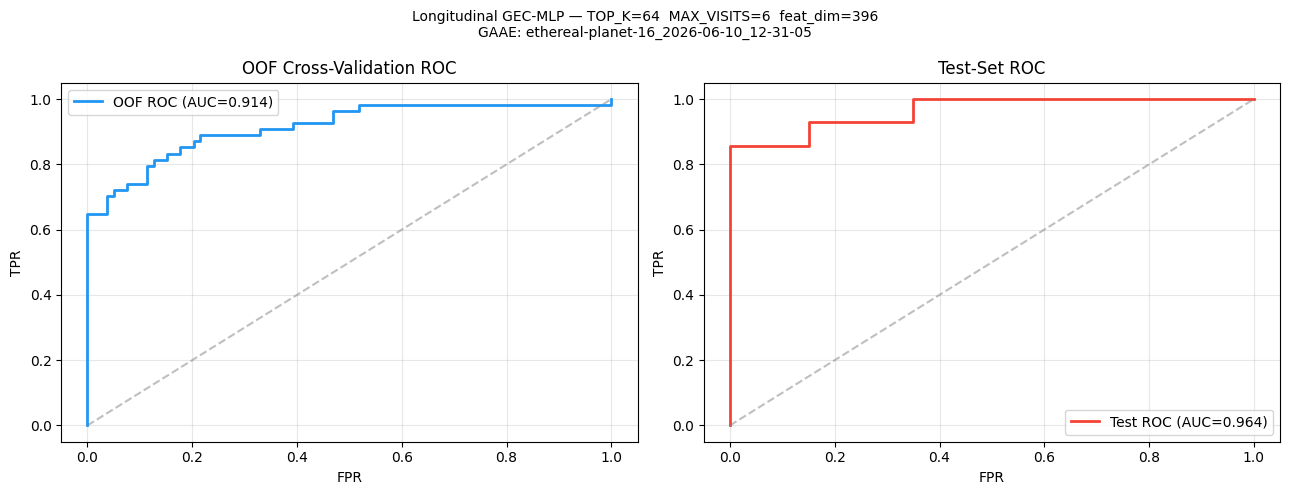

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: OOF ROC
ax = axes[0]
fpr_oof, tpr_oof, _ = roc_curve(oof_tgt, oof_arr)
auc_oof = roc_auc_score(oof_tgt, oof_arr)
ax.plot(fpr_oof, tpr_oof, lw=2, color='#2196F3',
        label=f'OOF ROC (AUC={auc_oof:.3f})')
ax.plot([0,1],[0,1],'--',color='grey',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('OOF Cross-Validation ROC')
ax.legend(); ax.grid(alpha=0.3)

# Right: test ROC
ax = axes[1]
fpr_te, tpr_te, _ = roc_curve(y_te.astype(int), te_probs)
ax.plot(fpr_te, tpr_te, lw=2, color='#F44336',
        label=f'Test ROC (AUC={te_auc:.3f})')
ax.plot([0,1],[0,1],'--',color='grey',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Test-Set ROC')
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle(
    f'Longitudinal GEC-MLP — TOP_K={TOP_K}  MAX_VISITS={MAX_VISITS}  '
    f'feat_dim={feat_dim}\n'
    f'GAAE: {GAAE_RUN_NAME}',
    fontsize=10,
)
plt.tight_layout(); plt.show()


## Early-Detection Curve: AUC vs. Number of Visits Used

For each `N`, take **all** test subjects with `T >= N` visits, truncate each
to their first `N` visits (zero-padded/masked to `MAX_VISITS` exactly as in
training), and re-run the trained model. This answers "if we only had the
first `N` visits, how well could we detect conversion?" — using the full test
set at every `N` (subject to the `len(grp) < 4` / single-class guard below).

**N=1 = single-scan / baseline-only classification.** This is not an
out-of-distribution input: the CV pool already contains 26/133 subjects
(test pool: 6/34) with exactly one visit, i.e. `mask=[1,0,0,0,0,0]`,
`Δt=[0,...,0]`. So the N=1 row directly answers "can this model classify a
patient from a single scan?" — yes, and it has seen this input pattern during
training.

In [23]:
print(f'\n{"Visits":>6} {"N":>4} {"AUC":>8} {"Sens":>8} {"Spec":>8}')
print('-' * 40)
for n_vis in range(1, MAX_VISITS + 1):
    sub_records = [rec for rec in te_records if rec['T'] >= n_vis]
    if len(sub_records) < 4:
        continue
    X_n, y_n, _ = records_to_arrays(sub_records, MAX_VISITS, n_visits=n_vis)
    if len(np.unique(y_n)) < 2:
        continue

    X_n_scaled = torch.tensor(best_scaler.transform(X_n), dtype=torch.float32)
    eval_mlp.eval()
    with torch.no_grad():
        probs_n = torch.sigmoid(eval_mlp(X_n_scaled.to(device))).cpu().numpy()

    auc_n  = roc_auc_score(y_n, probs_n)
    pred_n = (probs_n >= ACTIVE_THRESHOLD).astype(int)
    cm_n   = confusion_matrix(y_n.astype(int), pred_n)
    tn_, fp_, fn_, tp_ = cm_n.ravel() if cm_n.size == 4 else (0, 0, 0, 0)
    sens_n = tp_/(tp_+fn_+1e-9)
    spec_n = tn_/(tn_+fp_+1e-9)
    print(f'{n_vis:>6} {len(sub_records):>4} {auc_n:>8.4f} {sens_n:>8.3f} {spec_n:>8.3f}')



Visits    N      AUC     Sens     Spec
----------------------------------------
     1   34   0.5643    0.143    0.850
     2   28   0.9286    0.857    0.714
     3   18   0.9500    0.900    1.000
     4   12   0.9143    0.857    1.000
